708024

# Tarefa 4 - Random Forest com valores ausentes e K-means

Quarta tarefa avaliada da disciplina **Técnicas e Algoritmos em Ciência de Dados**.

Esta versão tem duas partes:

1. [Random Forest com valores ausentes](#Classification) (60%)
2. [Agrupamento com K-means](#K-Means) (40%)

Use o mesmo identificador aleatório de 6 dígitos usado nas tarefas anteriores e escreva-o na primeira célula do seu notebook submetido.

Você pode usar `numpy`, `pandas`, `matplotlib` e métricas de avaliação como AUROC. Você **não pode** usar implementações prontas de árvore de decisão, Random Forest, K-means ou ferramentas prontas de busca automática de parâmetros. Qualquer função auxiliar deve estar dentro deste notebook.


In [1]:
import math

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    PLOTTING_AVAILABLE = True
except ModuleNotFoundError:
    plt = None
    PLOTTING_AVAILABLE = False
    print("matplotlib não está instalado neste ambiente; ele será necessário para gerar os gráficos pedidos.")

try:
    display
except NameError:
    def display(obj):
        print(obj)


def roc_auc_score(y_true, y_score):
    """Calcula AUROC para rótulos binários, com tratamento correto de empates."""
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.asarray(y_score, dtype=float)
    positive = y_true == 1
    negative = y_true == 0
    n_pos = int(positive.sum())
    n_neg = int(negative.sum())
    if n_pos == 0 or n_neg == 0:
        raise ValueError("AUROC requer exemplos das duas classes.")

    order = np.argsort(y_score, kind="mergesort")
    sorted_scores = y_score[order]
    ranks = np.empty(len(y_score), dtype=float)
    start = 0
    while start < len(y_score):
        end = start + 1
        while end < len(y_score) and sorted_scores[end] == sorted_scores[start]:
            end += 1
        average_rank = (start + 1 + end) / 2.0
        ranks[order[start:end]] = average_rank
        start = end

    rank_sum_pos = ranks[positive].sum()
    return float((rank_sum_pos - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg))


<a id="Classification"></a>
## Parte 1 - Random Forest com valores ausentes (valor: 60%)

Você usará o arquivo `horse_colic_missing.csv`, baseado no conjunto Horse Colic. O alvo é `surgical_lesion`, em que `1` indica que o caso tinha lesão cirúrgica e `0` indica que não tinha.

Use apenas os atributos clínicos pré-desfecho listados abaixo. Não use `surgery`, `hospital_number`, `outcome`, códigos de lesão, `cp_data` ou outros campos que funcionem como identificadores, tratamento, desfecho ou vazamento de informação.

### Objetivo

Você pode reutilizar e adaptar suas implementações anteriores de árvore de decisão e Random Forest. O foco desta tarefa é modificar as árvores da floresta para lidar com valores ausentes durante a escolha das divisões, durante o treinamento e durante a predição.

### Estratégias obrigatórias para valores ausentes

Compare Florestas Aleatórias que diferem principalmente na forma como suas árvores tratam valores ausentes:

1. **Baseline simples de pré-processamento**: implemente uma referência simples, como imputação por mediana/moda aprendida apenas no treino. Essa estratégia serve como baseline.
2. **Roteamento fracionário por frequência de ramo**: ao avaliar uma divisão em um nó, use apenas os exemplos com valor observado naquele atributo para estimar as probabilidades dos ramos:

   ```text
   p_left = n_left_observed / n_observed
   p_right = n_right_observed / n_observed
   ```

   Os exemplos com valor ausente devem ser enviados para os dois filhos com esses pesos. A entropia, o ganho de informação e a frequência das classes nas folhas devem usar pesos: sempre que uma fórmula envolver contagem de exemplos, substitua a contagem pela soma dos pesos.

### O que entregar nesta parte

1. Carregue o conjunto de dados e descreva a fração de valores ausentes em cada atributo.
2. Faça a divisão treino/validação/teste com proporção 70/15/15 e `seed = 13`.
3. Adapte a árvore de decisão para usar pesos de amostras em entropia, ganho de informação e probabilidade da classe positiva nas folhas.
4. Armazene em cada nó interno as probabilidades de ramo estimadas a partir dos exemplos observados.
5. Implemente a predição para exemplos com valores ausentes usando o roteamento fracionário por frequência de ramo.
6. Implemente a Random Forest com bootstrap, subconjunto aleatório de atributos e agregação por média das probabilidades positivas ou média dos votos binários.
7. Escolha manualmente poucas combinações de hiperparâmetros usando AUROC na validação. Use `num_trees` entre 5 e 20 e profundidade máxima não superior a 5.
8. Treine novamente com treino + validação usando a melhor combinação de parâmetros e reporte acurácia com limiar 0.5 e AUROC no teste.
9. Compare as duas estratégias em uma tabela final e discuta qual funcionou melhor.


In [2]:
SEED = 13
TARGET = "surgical_lesion"
FEATURE_COLUMNS = [
    "age",
    "rectal_temperature",
    "pulse",
    "respiratory_rate",
    "temperature_of_extremities",
    "peripheral_pulse",
    "mucous_membranes",
    "capillary_refill_time",
    "pain",
    "peristalsis",
    "abdominal_distension",
    "nasogastric_tube",
    "nasogastric_reflux",
    "nasogastric_reflux_ph",
    "rectal_exam_feces",
    "abdomen",
    "packed_cell_volume",
    "total_protein",
    "abdominocentesis_appearance",
    "abdomcentesis_total_protein",
]
NUMERIC_COLUMNS = {
    "rectal_temperature",
    "pulse",
    "respiratory_rate",
    "nasogastric_reflux_ph",
    "packed_cell_volume",
    "total_protein",
    "abdomcentesis_total_protein",
}
CATEGORICAL_COLUMNS = [col for col in FEATURE_COLUMNS if col not in NUMERIC_COLUMNS]


df = pd.read_csv("horse_colic_missing.csv")
display(df.head())
missing_summary = df[FEATURE_COLUMNS].isna().mean().sort_values(ascending=False).rename("missing_fraction").to_frame()
display(missing_summary)


,source_split,age,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,peripheral_pulse,mucous_membranes,capillary_refill_time,pain,...,nasogastric_tube,nasogastric_reflux,nasogastric_reflux_ph,rectal_exam_feces,abdomen,packed_cell_volume,total_protein,abdominocentesis_appearance,abdomcentesis_total_protein,surgical_lesion
0,uci_train_file,1,38.5,66.0,28.0,3.0,3.0,NaN,2.0,5.0,...,NaN,NaN,NaN,3.0,5.0,45.0,8.4,NaN,NaN,0
1,uci_train_file,1,39.2,88.0,20.0,NaN,NaN,4.0,1.0,3.0,...,NaN,NaN,NaN,4.0,2.0,50.0,85.0,2.0,2.0,0
2,uci_train_file,1,38.3,40.0,24.0,1.0,1.0,3.0,1.0,3.0,...,NaN,NaN,NaN,1.0,1.0,33.0,6.7,NaN,NaN,0
3,uci_train_file,9,39.1,164.0,84.0,4.0,1.0,6.0,2.0,2.0,...,1.0,2.0,5.0,3.0,NaN,48.0,7.2,3.0,5.3,1
4,uci_train_file,1,37.3,104.0,35.0,NaN,NaN,6.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,74.0,7.4,NaN,NaN,0


,missing_fraction
nasogastric_reflux_ph,0.812500
abdomcentesis_total_protein,0.638587
abdominocentesis_appearance,0.527174
abdomen,0.388587
nasogastric_reflux,0.361413
nasogastric_tube,0.355978
rectal_exam_feces,0.347826
peripheral_pulse,0.225543
respiratory_rate,0.192935
rectal_temperature,0.187500


1. Divisão de conjunto de dados:

- Carregue o conjunto de dados fornecido em seu código.
- Divida o conjunto de dados em três conjuntos: treinamento, validação e teste,
com uma proporção de 70/15/15, respectivamente. Utilize seed = 13.

In [3]:
def stratified_split(df, target=TARGET, train_size=0.70, val_size=0.15, seed=SEED):
    rng = np.random.default_rng(seed)
    train_idx, val_idx, test_idx = [], [], []
    for _, group in df.groupby(target):
        idx = group.index.to_list()
        rng.shuffle(idx)
        n = len(idx)
        n_train = int(round(train_size * n))
        n_val = int(round(val_size * n))
        train_idx.extend(idx[:n_train])
        val_idx.extend(idx[n_train:n_train + n_val])
        test_idx.extend(idx[n_train + n_val:])
    return (
        df.loc[train_idx].sample(frac=1, random_state=seed).reset_index(drop=True),
        df.loc[val_idx].sample(frac=1, random_state=seed + 1).reset_index(drop=True),
        df.loc[test_idx].sample(frac=1, random_state=seed + 2).reset_index(drop=True),
    )


In [4]:
train_df, val_df, test_df = stratified_split(df)
y_train = train_df[TARGET].to_numpy(dtype=int)
y_val = val_df[TARGET].to_numpy(dtype=int)
y_test = test_df[TARGET].to_numpy(dtype=int)

print("Tamanhos treino/validação/teste:", len(train_df), len(val_df), len(test_df))
print("Distribuição do alvo no treino:", train_df[TARGET].value_counts(normalize=True).sort_index().to_dict())


Tamanhos treino/validação/teste: 257 55 56
Distribuição do alvo no treino: {0: 0.36964980544747084, 1: 0.6303501945525292}


In [5]:
train_df

,source_split,age,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,peripheral_pulse,mucous_membranes,capillary_refill_time,pain,...,nasogastric_tube,nasogastric_reflux,nasogastric_reflux_ph,rectal_exam_feces,abdomen,packed_cell_volume,total_protein,abdominocentesis_appearance,abdomcentesis_total_protein,surgical_lesion
0,uci_train_file,1,37.8,88.0,22.0,2.0,1.0,2.0,1.0,3.0,...,2.0,NaN,NaN,4.0,NaN,64.0,8.0,1.0,6.0,1
1,uci_train_file,1,37.8,60.0,24.0,1.0,NaN,3.0,2.0,NaN,...,2.0,3.0,2.0,NaN,5.0,52.0,75.0,NaN,NaN,1
2,uci_train_file,1,NaN,120.0,NaN,4.0,3.0,4.0,2.0,5.0,...,1.0,1.0,NaN,4.0,5.0,60.0,6.5,3.0,NaN,1
3,uci_train_file,1,38.2,64.0,24.0,1.0,1.0,3.0,1.0,4.0,...,2.0,1.0,NaN,4.0,4.0,45.0,7.5,1.0,2.0,1
4,uci_train_file,1,NaN,60.0,NaN,3.0,NaN,NaN,1.0,NaN,...,2.0,1.0,NaN,3.0,4.0,44.0,8.3,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252,uci_train_file,1,37.9,48.0,16.0,1.0,1.0,1.0,1.0,3.0,...,1.0,1.0,NaN,3.0,5.0,37.0,7.0,NaN,NaN,1
253,uci_test_file,1,NaN,75.0,12.0,1.0,1.0,4.0,1.0,5.0,...,NaN,3.0,5.8,NaN,NaN,58.0,8.5,1.0,NaN,1
254,uci_train_file,1,37.7,48.0,NaN,2.0,1.0,1.0,1.0,1.0,...,1.0,1.0,NaN,NaN,NaN,45.0,76.0,NaN,NaN,0
255,uci_test_file,1,38.0,72.0,36.0,1.0,1.0,3.0,1.0,3.0,...,2.0,1.0,NaN,3.0,5.0,38.0,6.8,2.0,2.0,0


In [6]:
valores_imputacao = {}
for col in FEATURE_COLUMNS:
    if col in NUMERIC_COLUMNS:
        valores_imputacao[col] = train_df[col].median()
    else:
        moda = train_df[col].mode()
        valores_imputacao[col] = moda.iloc[0] 

train_df_imp, val_df_imp, test_df_imp = train_df.copy(), val_df.copy(), test_df.copy()
for col, valor in valores_imputacao.items():
    train_df_imp[col] = train_df_imp[col].fillna(valor)
    val_df_imp[col]   = val_df_imp[col].fillna(valor)
    test_df_imp[col]  = test_df_imp[col].fillna(valor)

#Datasets para serem usados com roteamento fracionário
X_train_raw = train_df[FEATURE_COLUMNS].to_numpy(dtype=float)
X_val_raw   = val_df[FEATURE_COLUMNS].to_numpy(dtype=float)
X_test_raw  = test_df[FEATURE_COLUMNS].to_numpy(dtype=float)

#Datasets com imputação mediana/moda
X_train_imp = train_df_imp[FEATURE_COLUMNS].to_numpy(dtype=float)
X_val_imp   = val_df_imp[FEATURE_COLUMNS].to_numpy(dtype=float)
X_test_imp  = test_df_imp[FEATURE_COLUMNS].to_numpy(dtype=float)

### Árvore de decisão ponderada

Implemente abaixo a adaptação da árvore de decisão. Sua implementação deve incluir:

- entropia ponderada;
- ganho de informação ponderado;
- probabilidade positiva ponderada em cada folha;
- escolha de divisões ignorando valores ausentes apenas para calcular as frequências observadas dos ramos;
- envio fracionário dos exemplos ausentes para os dois filhos;
- armazenamento de `p_left` e `p_right` em cada nó interno para uso na predição.


In [7]:
def weighted_entropy(region: np.ndarray, w: np.ndarray):
    """Calcula a entropia para a classificação binária.

    Parameters
    ----------
        region (np.ndarray): Região para a qual a entropia vai ser calculada.
        w (np.ndarray): Array de pesos.

    Returns
    -------
        entropy (float): Entropia calculada. 
    """
    if region.size > 0:
        w_sum = w.sum()
        if w_sum == 0:
            return float("inf")
        
        p1 = np.dot(region, w)/w_sum
        
    else: 
        return float("inf")
    
    p0 = 1 - p1
    entropy = -p1 * np.log2(p1+1e-8) - p0 * np.log2(p0+1e-8) 
    
    return entropy


def weighted_classification_criterion(region: np.ndarray, w: np.ndarray, w_total: float):
    """Calcula a parcela do ganho de informação referente a região, utilizando a entropia ponderada.

    Parameters
    ----------
        region (np.ndarray): Região para a qual a parcela do ganho de informação será calculada.
        w (np.ndarray): Array de pesos da região.
        w_total (float): Soma dos pesos da região antes do split.

    Returns
    -------
        (float): 
            Parcela do ganho de informação referente a região passada como parâmetro.
    """
    w_sum = w.sum()
    if w_total == 0 or w_sum == 0:
        return 0.0
    return (w_sum / w_total) * weighted_entropy(region, w)

In [8]:
# Escreva aqui a implementação da árvore de decisão ponderada e do
# roteamento fracionário por frequência de ramo.

def bootstrap(X, num_bags=10):
    """
    Given a dataset and a number of bags,
    sample the dataset with replacement.
    
    This function does not return a copy
    of the datapoints, but a list of indices
    with compatible dimensionality
    
    Parameters
    ----------
    X : ndarray
        A dataset
    num_bags : int, default 10
        The number of bags to create
    
    Returns
    -------
    list of ndarray
        The list contains `num_bags` integer one-dimensional ndarrays.
        Each of these contains the indices corresponding to the 
        sampled datapoints in `X`
    
    Notes
    -----
    * The number of datapoints in each bach will
      match the number of datapoints in the given
      dataset.
    * The
    """
    rng = np.random.default_rng(0) 
    n_samples = X.shape[0]
    return [rng.integers(0, n_samples, size=n_samples) for i in range(num_bags)]

def split_region(region, feature_index, tau):
    """
    Given a region, splits it based on the feature indicated by
    `feature_index`, the region will be split in two, where
    one side will contain all points with the feature with values 
    lower than `tau`, and the other split will contain the 
    remaining datapoints.
    
    Parameters
    ----------
    region : array of size (n_samples, n_features)
        a partition of the dataset (or the full dataset) to be split
    feature_index : int
        the index of the feature (column of the region array) used to make this partition
    tau : float
        The threshold used to make this partition
        
    Return
    ------
    left_partition : array
        indices of the datapoints in `region` where feature < `tau`
    right_partition : array
        indices of the datapoints in `region` where feature >= `tau` 
    """
    
    left_partition = region[:, feature_index] < tau
    right_partition = region[:, feature_index] >= tau
    
    return left_partition, right_partition

def get_split(X, y, w, num_features= None, rng= None):
    """
    Given a dataset (full or partial), splits it on the feature of that minimizes the sum of squared error
    
    Parameters
    ----------
    X : array (n_samples, n_features)
        features 
    y : array (n_samples, )
        labels
    
    Returns
    -------
    decision : dictionary
        keys are:
        * 'feature_index' -> an integer that indicates the feature (column) of `X` on which the data is split
        * 'tau' -> the threshold used to make the split
        * 'left_region' -> array of indices where the `feature_index`th feature of X is lower than `tau`
        * 'right_region' -> indices not in `low_region`
    """
        
    n_samples, n_features = X.shape
    
    best_gain = -float("inf")
    best_feature = 0
    best_tau = 0
    best_left_indices = np.array([], dtype=int)
    best_right_indices = np.array([], dtype=int)
    best_p_left = 0.5
    best_p_right = 0.5 
    
    w_total = w.sum()
    if w_total == 0:
        return {"value": 0.5}
    
    current_entropy = weighted_entropy(y, w) 
    
    k = num_features or max(1, int(np.sqrt(n_features)))
    features_to_test = rng.choice(n_features, size=k, replace=False)
    
    for feature_idx in features_to_test:
        coluna = X[:, feature_idx]
        not_nan_idx = np.where(~np.isnan(coluna))[0]
        
        w_not_nan = w[not_nan_idx]
        w_not_nan_total = w_not_nan.sum()
        thresholds = np.unique(coluna[not_nan_idx])

        for tau in thresholds:
            left_mask, right_mask = split_region(X[not_nan_idx], feature_idx, tau)
            left_indices, right_indices = not_nan_idx[left_mask], not_nan_idx[right_mask]
            
            w_left, w_right = w[left_indices], w[right_indices]
            
            information_gain = current_entropy - (weighted_classification_criterion(y[left_indices], w_left, w_total) + weighted_classification_criterion(y[right_indices], w_right, w_total))
            
            if information_gain > best_gain:
                best_gain = information_gain
                best_feature = feature_idx
                best_tau = tau
                best_left_indices = left_indices
                best_right_indices = right_indices
                best_p_left    = w_left.sum()  / w_not_nan_total if w_not_nan_total > 0 else 0.5
                best_p_right   = w_right.sum() / w_not_nan_total if w_not_nan_total > 0 else 0.5
                
    if best_gain == -float("inf"):
        return {"value": np.dot(y, w) / w.sum() if w.sum() > 0 else 0.5}
                
    return {'feature_index': int(best_feature),
            'tau': float(best_tau),
            'left_region': best_left_indices,
            'right_region': best_right_indices,
            'p_left':        float(best_p_left),
            'p_right':       float(best_p_right)}
    

def recursive_growth(node, min_samples, max_depth, current_depth, X, y, w, num_features = None, rng= None):
    """
    Recursively grows a decision tree.
    
    Parameters
    ----------
    node : dictionary
        If the node is terminal, it contains only the "value" key, which determines the value to be used as a prediction.
        If the node is not terminal, the dictionary has the structure defined by `get_split`
    min_samples : int
        parameter for stopping criterion if a node has <= min_samples datapoints
    max_depth : int
        parameter for stopping criterion if a node belongs to this depth
    depth : int
        current distance from the root
    X : array (n_samples, n_features)
        features (full dataset)
    y : array (n_samples, )
        labels (full dataset)
    
    Notes
    -----
    To create a terminal node, a dictionary is created with a single "value" key, with a value that
    is the mean of the target variable
    
    'left' and 'right' keys are added to non-terminal nodes, which contain (possibly terminal) nodes 
    from higher levels of the tree:
    'left' corresponds to the 'left_region' key, and 'right' to the 'right_region' key
    """
    feature_idx = node["feature_index"]
    p_left, p_right = node["p_left"], node["p_right"]
    
    coluna      = X[:, feature_idx]
    nan_idx     = np.where(np.isnan(coluna))[0]
    
    left_indices, right_indices = np.concatenate([node["left_region"], nan_idx]), np.concatenate([node["right_region"], nan_idx])
    
    w_left, w_right  = np.concatenate([w[node["left_region"]],  w[nan_idx] * p_left]), np.concatenate([w[node["right_region"]], w[nan_idx] * p_right])
    
    X_left, y_left = X[left_indices], y[left_indices]
    X_right, y_right = X[right_indices], y[right_indices]
    
    if (len(y_left) < min_samples or current_depth >= max_depth or weighted_entropy(y_left, w_left) == 0):
        node["left_region"] = {"value": np.dot(y_left, w_left) / w_left.sum() if w_left.sum() > 0 else 0.5}
    else:
        split_left = get_split(X_left, y_left, w_left, num_features, rng)
        node["left_region"] = split_left
        if "value" not in split_left:
            recursive_growth(split_left, min_samples, max_depth, current_depth + 1, X_left, y_left, w_left, num_features, rng)
    
    if (len(y_right) < min_samples or current_depth >= max_depth or weighted_entropy(y_right, w_right) == 0):
        node["right_region"] = {"value": np.dot(y_right, w_right) / w_right.sum() if w_right.sum() > 0 else 0.5}
    else:
        split_right = get_split(X_right, y_right, w_right, num_features, rng)
        node["right_region"] = split_right
        if "value" not in split_right:
            recursive_growth(split_right, min_samples, max_depth, current_depth + 1, X_right, y_right, w_right, num_features, rng)
        

def predict_sample(node, sample):
    """
    Makes a prediction based on the decision tree defined by `node`
    
    Parameters
    ----------
    node : dictionary
        A node created one of the methods above
    sample : array of size (n_features,)
        a sample datapoint
    """
    if "value" in node:
        return node["value"]
    
    val = sample[node["feature_index"]]
    
    if np.isnan(val):
        pred_left = predict_sample(node["left_region"], sample)
        pred_right = predict_sample(node["right_region"], sample)
        
        return node["p_left"] * pred_left + node["p_right"] * pred_right
    
    if val < node["tau"]:
        return predict_sample(node["left_region"], sample)
    else:
        return predict_sample(node["right_region"], sample)
    
        
def predict(node, X):
    """
    Makes a prediction based on the decision tree defined by `node`
    
    Parameters
    ----------
    node : dictionary
        A node created one of the methods above
    X : array of size (n_samples, n_features)
        n_samples predictions will be made
    """
    return np.array([predict_sample(node, sample) for sample in X])



class RandomForestClassifier:
    def __init__(self, n_estimators=10, max_depth=None, num_features=None, min_samples=1, threshold= 0.5):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.num_features = num_features
        self.min_samples = min_samples
        self.threshold = threshold
        self.trees = []
    
    
    def build_tree(self, X, y, w= None, rng= None):
        if w is None:
            w = np.ones(len(y), dtype=float)
    
        root = get_split(X, y, w, self.num_features, rng)
        if "value" not in root:
            recursive_growth(root, self.min_samples, self.max_depth, 1, X, y, w, self.num_features, rng)
        return root

    def fit(self, X, y):
        rng = np.random.default_rng(SEED)
        bags = bootstrap(X, num_bags= self.n_estimators)
    
        for bag in bags:

            X_bag = X[bag]
            y_bag = y[bag]
            w_bag = np.ones(len(y_bag), dtype=float)
    
            root = self.build_tree(X_bag, y_bag, w= w_bag, rng= rng)
            self.trees.append(root)
    
    def predict_proba(self, X):
        """Returns P(y=1) averaged across all trees."""
        preds = [
            predict(root, X)
            for root in self.trees
        ]
        return np.mean(np.column_stack(preds), axis=1)
    
    def predict(self, X):
        return (self.predict_proba(X) >= self.threshold).astype(int)
    

### Random Forest e comparação das estratégias

Implemente abaixo a Random Forest. A comparação final deve isolar principalmente a estratégia de tratamento de valores ausentes:

- baseline com imputação mediana/moda aprendida apenas no treino;
- árvore com roteamento fracionário por frequência de ramo.

Use bootstrap para cada árvore e um subconjunto aleatório de atributos por árvore. Escolha manualmente alguns valores para `num_trees`, `max_depth` e outros critérios de parada usando AUROC na validação. Depois, treine com treino + validação e avalie no teste.


In [9]:
max_depths = [2, 3, 4, 5]
num_features_list = [5, 10, 15, 20] 
best_auroc = 0
min_samples = [2,3,5]
n_estimators = [5, 10, 20]

for max_depth in max_depths:
    for num_features in num_features_list:
        for min_sample in min_samples:
            for n_estimator in n_estimators:
                rf = RandomForestClassifier(n_estimators=n_estimator, max_depth=max_depth, num_features=num_features, min_samples=min_sample, threshold= 0.5)
                rf.fit(X_train_imp, y_train)
                y_pred = rf.predict(X_val_imp)
                auroc_val = roc_auc_score(y_val, rf.predict_proba(X_val_imp))
                print(f"AUROC on validation set with max_depth={max_depth}, num_features={num_features}, min_samples={min_sample}, n_estimators={n_estimator}: {auroc_val:.2f}")
                
                if auroc_val > best_auroc:
                    best_auroc = auroc_val
                    best_params_imp = (max_depth, num_features, min_sample, n_estimator)

print(f"Best AUROC: {best_auroc:.2f} with parameters: max_depth={best_params_imp[0]}, num_features={best_params_imp[1]}, min_samples={best_params_imp[2]}, n_estimators={best_params_imp[3]}")

rf_final = RandomForestClassifier(n_estimators=best_params_imp[3], max_depth=best_params_imp[0], num_features=best_params_imp[1], min_samples=best_params_imp[2])

X_imp_final = np.vstack((X_train_imp, X_val_imp))
y_final = np.hstack((y_train, y_val))
rf_final.fit(X_imp_final, y_final)

y_test_pred = rf_final.predict_proba(X_test_imp)

auroc_test = roc_auc_score(y_test, y_test_pred)
print(f"AUROC on test set: {auroc_test:.2f}")

AUROC on validation set with max_depth=2, num_features=5, min_samples=2, n_estimators=5: 0.58
AUROC on validation set with max_depth=2, num_features=5, min_samples=2, n_estimators=10: 0.60
AUROC on validation set with max_depth=2, num_features=5, min_samples=2, n_estimators=20: 0.61
AUROC on validation set with max_depth=2, num_features=5, min_samples=3, n_estimators=5: 0.58
AUROC on validation set with max_depth=2, num_features=5, min_samples=3, n_estimators=10: 0.60
AUROC on validation set with max_depth=2, num_features=5, min_samples=3, n_estimators=20: 0.61
AUROC on validation set with max_depth=2, num_features=5, min_samples=5, n_estimators=5: 0.58
AUROC on validation set with max_depth=2, num_features=5, min_samples=5, n_estimators=10: 0.60
AUROC on validation set with max_depth=2, num_features=5, min_samples=5, n_estimators=20: 0.61
AUROC on validation set with max_depth=2, num_features=10, min_samples=2, n_estimators=5: 0.61
AUROC on validation set with max_depth=2, num_feature

In [10]:
max_depths = [2, 3, 4, 5]
num_features_list = [5, 10, 15, 20] 
best_auroc = 0
min_samples = [2,3,5]
n_estimators = [5, 10, 20]

for max_depth in max_depths:
    for num_features in num_features_list:
        for min_sample in min_samples:
            for n_estimator in n_estimators:
                rf = RandomForestClassifier(n_estimators=n_estimator, max_depth=max_depth, num_features=num_features, min_samples=min_sample, threshold= 0.5)
                rf.fit(X_train_raw, y_train)
                y_pred = rf.predict(X_val_raw)
                auroc_val = roc_auc_score(y_val, rf.predict_proba(X_val_raw))
                print(f"AUROC on validation set with max_depth={max_depth}, num_features={num_features}, min_samples={min_sample}, n_estimators={n_estimator}: {auroc_val:.2f}")
                
                if auroc_val > best_auroc:
                    best_auroc = auroc_val
                    best_params_raw = (max_depth, num_features, min_sample, n_estimator)

print(f"Best AUROC: {best_auroc:.2f} with parameters: max_depth={best_params_raw[0]}, num_features={best_params_raw[1]}, min_samples={best_params_raw[2]}, n_estimators={best_params_raw[3]}")

rf_final = RandomForestClassifier(n_estimators=best_params_raw[3], max_depth=best_params_raw[0], num_features=best_params_raw[1], min_samples=best_params_raw[2])

X_raw_final = np.vstack((X_train_raw, X_val_raw))
rf_final.fit(X_raw_final, y_final)

y_test_pred = rf_final.predict_proba(X_test_raw)

auroc_test = roc_auc_score(y_test, y_test_pred)
print(f"AUROC on test set: {auroc_test:.2f}")

AUROC on validation set with max_depth=2, num_features=5, min_samples=2, n_estimators=5: 0.72
AUROC on validation set with max_depth=2, num_features=5, min_samples=2, n_estimators=10: 0.71
AUROC on validation set with max_depth=2, num_features=5, min_samples=2, n_estimators=20: 0.76
AUROC on validation set with max_depth=2, num_features=5, min_samples=3, n_estimators=5: 0.72
AUROC on validation set with max_depth=2, num_features=5, min_samples=3, n_estimators=10: 0.71
AUROC on validation set with max_depth=2, num_features=5, min_samples=3, n_estimators=20: 0.76
AUROC on validation set with max_depth=2, num_features=5, min_samples=5, n_estimators=5: 0.72
AUROC on validation set with max_depth=2, num_features=5, min_samples=5, n_estimators=10: 0.71
AUROC on validation set with max_depth=2, num_features=5, min_samples=5, n_estimators=20: 0.76
AUROC on validation set with max_depth=2, num_features=10, min_samples=2, n_estimators=5: 0.74
AUROC on validation set with max_depth=2, num_feature

In [11]:
modelo_final_imp = RandomForestClassifier(n_estimators=best_params_imp[3], max_depth=best_params_imp[0], min_samples=2)
modelo_final_imp.fit(X_imp_final, y_final)
probs_teste_imp = modelo_final_imp.predict_proba(X_test_imp)
preds_teste_imp = modelo_final_imp.predict(X_test_imp)

auroc_teste_imp = roc_auc_score(y_test, probs_teste_imp)
acc_teste_imp = np.mean(y_test == preds_teste_imp)

modelo_final_raw = RandomForestClassifier(n_estimators=best_params_raw[3], max_depth=best_params_raw[0], min_samples=2)
modelo_final_raw.fit(X_raw_final, y_final)
probs_teste_raw = modelo_final_raw.predict_proba(X_test_raw)
preds_teste_raw = modelo_final_raw.predict(X_test_raw)

auroc_teste_raw = roc_auc_score(y_test, probs_teste_raw)
acc_teste_raw = np.mean(y_test == preds_teste_raw)

tabela_resultados = pd.DataFrame({
    "Estratégia para Valores Ausentes": ["Baseline (Imputação Mediana/Moda)", "Roteamento Fracionário por Ramo"], 
    "Hiperparâmetros Ótimos (Árvores, Profundidade)": [f"({best_params_imp[3]}, {best_params_imp[0]})", f"({best_params_raw[3]}, {best_params_raw[0]})"],
    "Acuraccy": [f"{acc_teste_imp:.4f}", f"{acc_teste_raw:.4f}"], 
    "AUROC": [f"{auroc_teste_imp:.4f}", f"{auroc_teste_raw:.4f}"]
})

display(tabela_resultados)

,Estratégia para Valores Ausentes,"Hiperparâmetros Ótimos (Árvores, Profundidade)",Acuraccy,AUROC
0,Baseline (Imputação Mediana/Moda),"(20, 3)",0.7500,0.7762
1,Roteamento Fracionário por Ramo,"(10, 4)",0.7143,0.7687


<a id="K-Means"></a>
## Parte 2 - Agrupamento com K-means (valor: 40%)

Nesta parte, implemente K-means do zero usando os pontos artificiais abaixo. O objetivo é visualizar o movimento dos centroides e analisar a soma das distâncias quadradas.

Requisitos:

1. Use `K = 3`, `epsilon = 1e-4`, `max_iter = 150` e seed `13`.
2. Inicialize os centroides escolhendo `K` pontos do conjunto de dados sem reposição.
3. Em cada iteração:
   - atribua cada ponto ao centroide mais próximo usando distância euclidiana;
   - atualize cada centroide para a média dos pontos atribuídos ao cluster;
   - se um cluster não receber pontos, mantenha o centroide anterior desse cluster;
   - calcule e armazene a soma das distâncias quadradas.
4. Use a norma euclidiana do deslocamento conjunto dos centroides como critério de convergência. Pare quando ela for menor que `epsilon`.
5. Armazene o histórico de centroides, rótulos de cluster e soma das distâncias quadradas.
6. Plote 5 momentos determinísticos: estado inicial antes do aprendizado, estado final e três estados intermediários igualmente espaçados. Se houver menos de 5 estados, repita estados disponíveis sem inventar novas iterações.
7. Plote também a soma das distâncias quadradas ao longo das iterações.


In [12]:
K = 3
EPSILON = 1e-4
MAX_ITER = 150

np.random.seed(SEED)
num_samples = 200
num_features = 2
X = np.random.randn(num_samples, num_features) * 1.5 + np.array([[2, 2]])
X = np.concatenate([X, np.random.randn(num_samples, num_features) * 3 + np.array([[-5, -5]])])
X = np.concatenate([X, np.random.randn(num_samples, num_features) * 2 + np.array([[7, -5]])])

print(X.shape)


(600, 2)


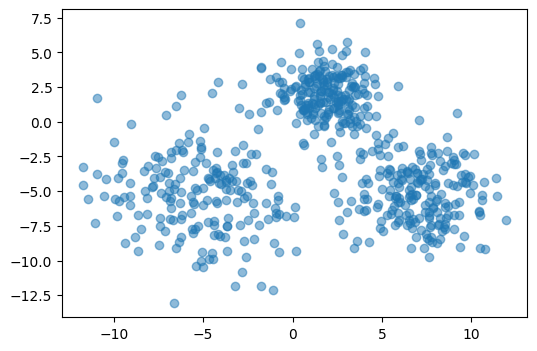

In [13]:
fig = plt.figure(figsize=(6,4))
plt.scatter(X[:,0], X[:,1], alpha= 0.5)
plt.show()

In [14]:
# Escreva aqui sua implementação de K-means, os gráficos dos 5 momentos
# e o gráfico da soma das distâncias quadradas.

class Kmeans:
    def __init__(self, K, max_iter, stop_criterion, seed):
        self.K = K
        self.max_iter = max_iter
        self.stop_criterion = stop_criterion
        self.seed = seed
        self.centroids = None
        self.cluster = None
        
        self.centroids_history = []
        self.labels_history = []
        self.ss_history = []
    
    @staticmethod
    def euclidiean_dist(p1, p2):
        return np.sqrt(np.sum((p1 - p2)**2))
    
    def predict(self, X):
        ss = 0
        
        for i, point in enumerate(X):
            distances = []
            
            for centroid in self.centroids:
                distances.append(self.euclidiean_dist(point, centroid))
            
            ss += min(distances)**2
            self.cluster[i] = distances.index(min(distances))
            
        return self.cluster, ss
        
    def fit(self, X):
        rng = np.random.default_rng(self.seed)
        self.cluster = np.empty(X.shape[0])
        
        initial_indices = rng.choice(X.shape[0], size=self.K, replace=False)
        self.centroids = X[initial_indices].copy()
        
        labels, ss = self.predict(X)
        self.centroids_history.append(self.centroids.copy())
        self.labels_history.append(labels.copy())
        self.ss_history.append(ss)
        
        for i in range(self.max_iter):
            previous = self.centroids.copy()
            
            for cluster_idx in range(self.K):
                cluster_mask = self.cluster == cluster_idx
                
                if np.sum(cluster_mask) > 0:
                    self.centroids[cluster_idx] = np.average(X[cluster_mask], axis=0)
            
            labels, ss = self.predict(X)
            
            self.centroids_history.append(self.centroids.copy())
            self.labels_history.append(labels.copy())
            self.ss_history.append(ss)
            
            stop = True
            
                
            if self.euclidiean_dist(previous, self.centroids) > self.stop_criterion:
                stop = False
            
            if stop:
                break
            

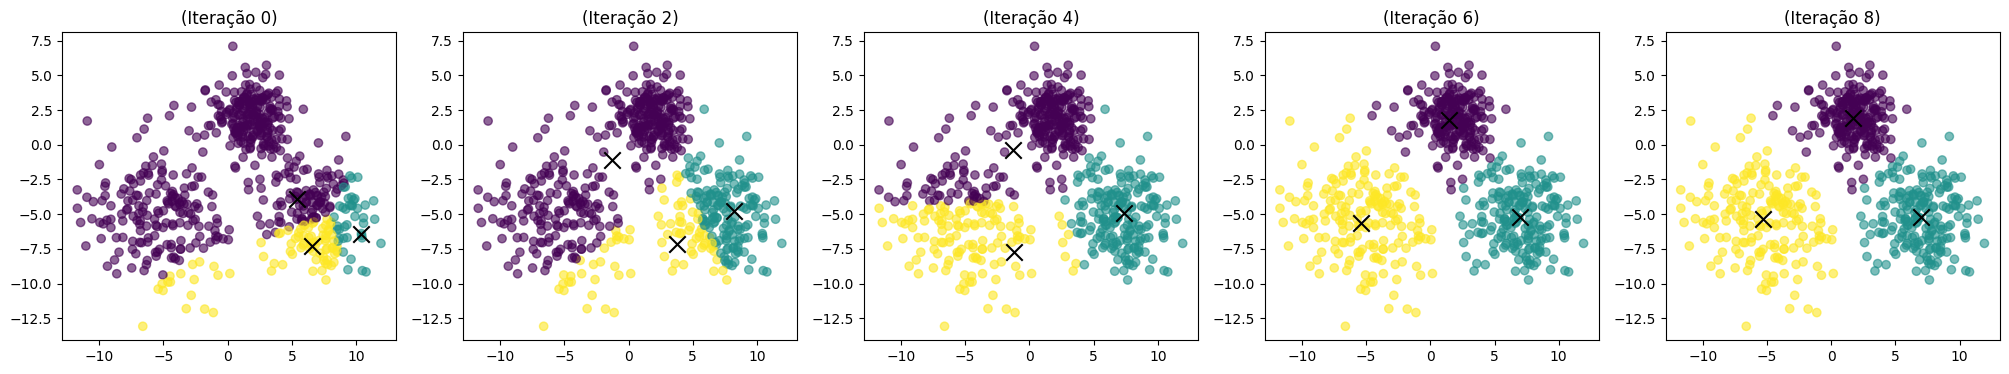

In [15]:
k_means = Kmeans(K= K, max_iter= MAX_ITER, stop_criterion= EPSILON, seed= SEED)
k_means.fit(X)

total_estados = len(k_means.centroids_history)

if total_estados >= 5:
    indices_plots = [0, int(round((total_estados - 1) * 0.25)), int(round((total_estados - 1) * 0.50)), int(round((total_estados - 1) * 0.75)), total_estados - 1]
else:
    indices_plots = [i for i in range(total_estados)]
    for i in range(5 - total_estados):
        indices_plots.append(total_estados - 1)

fig, axes = plt.subplots(1, 5, figsize=(25, 4))

for ax, idx in zip(axes, indices_plots):
    centroids = k_means.centroids_history[idx]
    labels = k_means.labels_history[idx]
    
    ax.scatter(X[:, 0], X[:, 1], c=labels, alpha=0.6)

    plot_centroides = ax.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='x', s=140)
    ax.set_title(f"(Iteração {idx})")

plt.show()

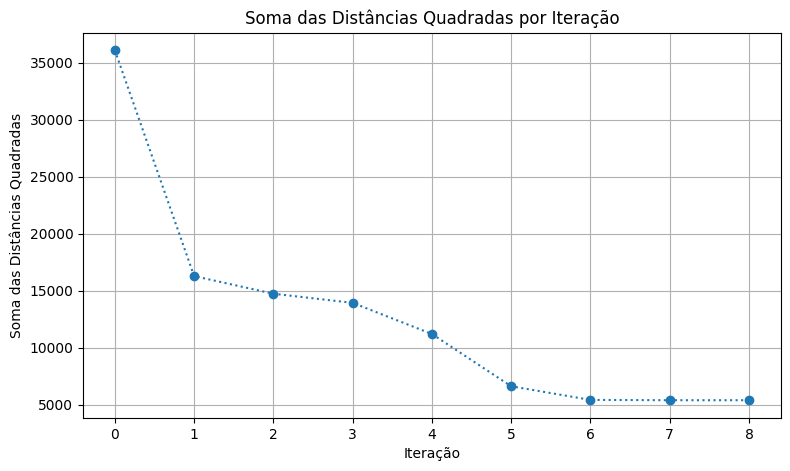

In [16]:
plt.figure(figsize=(9, 5))
plt.plot(range(total_estados), k_means.ss_history, marker= "o", linestyle= ":")
plt.title("Soma das Distâncias Quadradas por Iteração")
plt.xlabel("Iteração")
plt.ylabel("Soma das Distâncias Quadradas")
plt.grid(True)
plt.show()